<a href="https://colab.research.google.com/github/angelaoica-dev/challenge-TelecomX/blob/main/TelecomXLatam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📚 Bibliotecas y librerias

In [1]:
import pandas as pd
import json
import requests
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

#📌 Extracción

In [6]:
url = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'
response = requests.get(url)
df = pd.json_normalize(data=json.loads(response.text))
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

### **Diccionario de datos del conjunto de datos**



* customerID: número de identificación único de cada cliente
* Churn: si el cliente dejó o no la empresa
* gender: género (masculino y femenino)
* SeniorCitizen: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
* Partner: si el cliente tiene o no una pareja
* Dependents: si el cliente tiene o no dependientes
* tenure: meses de contrato del cliente
* PhoneService: suscripción al servicio telefónico
* MultipleLines: suscripción a más de una línea telefónica
* InternetService: suscripción a un proveedor de internet
* OnlineSecurity: suscripción adicional de seguridad en línea
* OnlineBackup: suscripción adicional de respaldo en línea
* DeviceProtection: suscripción adicional de protección del dispositivo
* TechSupport: suscripción adicional de soporte técnico, menor tiempo de espera
* StreamingTV: suscripción de televisión por cable
* StreamingMovies: suscripción de streaming de películas
* Contract: tipo de contrato
* PaperlessBilling: si el cliente prefiere recibir la factura en línea
* PaymentMethod: forma de pago
* Charges.Monthly: total de todos los servicios del cliente por mes
* Charges.Total: total gastado por el cliente

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [9]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [11]:
#Registros duplicados
df.duplicated().sum()

np.int64(0)

In [15]:
# Verificación de los valores únicos
for column in df.columns[1:]:
    unique_values = df[column].sort_values().unique()
    if len(unique_values) < 10:
        print(column, '\n',unique_values, '\n')
    else:
        print(column, '\nMin:',min(unique_values), '\t Max:', max(unique_values), '\n')

Churn 
 ['' 'No' 'Yes'] 

customer.gender 
 ['Female' 'Male'] 

customer.SeniorCitizen 
 [0 1] 

customer.Partner 
 ['No' 'Yes'] 

customer.Dependents 
 ['No' 'Yes'] 

customer.tenure 
Min: 0 	 Max: 72 

phone.PhoneService 
 ['No' 'Yes'] 

phone.MultipleLines 
 ['No' 'No phone service' 'Yes'] 

internet.InternetService 
 ['DSL' 'Fiber optic' 'No'] 

internet.OnlineSecurity 
 ['No' 'No internet service' 'Yes'] 

internet.OnlineBackup 
 ['No' 'No internet service' 'Yes'] 

internet.DeviceProtection 
 ['No' 'No internet service' 'Yes'] 

internet.TechSupport 
 ['No' 'No internet service' 'Yes'] 

internet.StreamingTV 
 ['No' 'No internet service' 'Yes'] 

internet.StreamingMovies 
 ['No' 'No internet service' 'Yes'] 

account.Contract 
 ['Month-to-month' 'One year' 'Two year'] 

account.PaperlessBilling 
 ['No' 'Yes'] 

account.PaymentMethod 
 ['Bank transfer (automatic)' 'Credit card (automatic)' 'Electronic check'
 'Mailed check'] 

account.Charges.Monthly 
Min: 18.25 	 Max: 118.75 

ac

In [17]:
df['account.Charges.Total'].isnull().any()

np.False_

In [18]:
# Conviertir todo a string y buscar los que no son números válidos
no_numericos = df.loc[~df['account.Charges.Total'].astype(str).str.replace('.', '', 1).str.isnumeric(),
                      'account.Charges.Total']
print(no_numericos.head())

975      
1775     
1955     
2075     
2232     
Name: account.Charges.Total, dtype: object


In [19]:
df['account.Charges.Total'] = pd.to_numeric(
    df['account.Charges.Total'].astype(str).str.replace(r'\s+', '', regex=True),
    errors='coerce')

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [22]:
df[df['account.Charges.Total'].isna()]

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,...,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,NaN
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN
2308,3213-VVOLG,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN
2930,4075-WKNIU,No,Female,0,Yes,Yes,0,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN
3134,4367-NUYAO,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN
3203,4472-LVYGI,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN
4169,5709-LVOEQ,No,Female,0,Yes,Yes,0,Yes,No,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN


In [25]:
df['account.Charges.Total'].fillna(0, inplace=True)
df.query("`account.Charges.Total` == 0")

/tmp/ipykernel_474/1958766318.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['account.Charges.Total'].fillna(0, inplace=True)


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,0.0
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,0.0
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,...,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,0.0
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,0.0
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,0.0
2308,3213-VVOLG,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,0.0
2930,4075-WKNIU,No,Female,0,Yes,Yes,0,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,0.0
3134,4367-NUYAO,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,0.0
3203,4472-LVYGI,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,0.0
4169,5709-LVOEQ,No,Female,0,Yes,Yes,0,Yes,No,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,0.0


###Comprobación de incoherencias en los datos

In [26]:
#validar los datos de cada columna para identificar inconsistencias

for columna in df.columns:
    print(columna)
    print(df[columna].unique())

customerID
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
Churn
['No' 'Yes' '']
customer.gender
['Female' 'Male']
customer.SeniorCitizen
[0 1]
customer.Partner
['Yes' 'No']
customer.Dependents
['Yes' 'No']
customer.tenure
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]
phone.PhoneService
['Yes' 'No']
phone.MultipleLines
['No' 'Yes' 'No phone service']
internet.InternetService
['DSL' 'Fiber optic' 'No']
internet.OnlineSecurity
['No' 'Yes' 'No internet service']
internet.OnlineBackup
['Yes' 'No' 'No internet service']
internet.DeviceProtection
['No' 'Yes' 'No internet service']
internet.TechSupport
['Yes' 'No' 'No internet service']
internet.StreamingTV
['Yes' 'No' 'No internet service']
internet.StreamingMovies
['No' 'Yes' 'No internet service']
account.Contract
['One year' 'M

In [27]:
# Reemplazar valores
df.replace(['No internet service', 'No phone service'],'No', inplace=True)

# Revisar valores únicos
for col in df.select_dtypes(include='object'):
    print(f"\n{col}: {df[col].unique()}")


customerID: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']

Churn: ['No' 'Yes' '']

customer.gender: ['Female' 'Male']

customer.Partner: ['Yes' 'No']

customer.Dependents: ['Yes' 'No']

phone.PhoneService: ['Yes' 'No']

phone.MultipleLines: ['No' 'Yes']

internet.InternetService: ['DSL' 'Fiber optic' 'No']

internet.OnlineSecurity: ['No' 'Yes']

internet.OnlineBackup: ['Yes' 'No']

internet.DeviceProtection: ['No' 'Yes']

internet.TechSupport: ['Yes' 'No']

internet.StreamingTV: ['Yes' 'No']

internet.StreamingMovies: ['No' 'Yes']

account.Contract: ['One year' 'Month-to-month' 'Two year']

account.PaperlessBilling: ['Yes' 'No']

account.PaymentMethod: ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']


In [29]:
valores_validos = {
    'Churn': ['Yes', 'No'],
    'customer.gender': ['Male', 'Female'],
    'customer.SeniorCitizen': [0, 1],
    'customer.Partner': ['Yes', 'No'],
    'customer.Dependents': ['Yes', 'No'],
    'phone.PhoneService': ['Yes', 'No'],
    'phone.MultipleLines': ['Yes', 'No', 'No phone service'],
    'internet.InternetService': ['DSL', 'Fiber optic', 'No'],
    'account.Contract': ['Month-to-month', 'One year', 'Two year'],
    'account.PaperlessBilling': ['Yes', 'No'],
    'account.PaymentMethod': [
        'Electronic check',
        'Mailed check',
        'Bank transfer (automatic)',
        'Credit card (automatic)'
    ]
}

for columna, valores in valores_validos.items():
    filtro = df[columna].isin(valores)
    print(f"{columna} -> valores incoherentes: {len(df[~filtro])}")

Churn -> valores incoherentes: 224
customer.gender -> valores incoherentes: 0
customer.SeniorCitizen -> valores incoherentes: 0
customer.Partner -> valores incoherentes: 0
customer.Dependents -> valores incoherentes: 0
phone.PhoneService -> valores incoherentes: 0
phone.MultipleLines -> valores incoherentes: 0
internet.InternetService -> valores incoherentes: 0
account.Contract -> valores incoherentes: 0
account.PaperlessBilling -> valores incoherentes: 0
account.PaymentMethod -> valores incoherentes: 0


In [30]:
#Verificación de columnas dependientes de Internet
columnas_internet = [
    'internet.OnlineSecurity',
    'internet.OnlineBackup',
    'internet.DeviceProtection',
    'internet.TechSupport',
    'internet.StreamingTV',
    'internet.StreamingMovies'
]

for col in columnas_internet:
    filtro = (
        (~df[col].isin(['Yes', 'No', 'No internet service'])) |
        ((df['internet.InternetService'] == 'No') &
         (df[col] != 'No internet service'))
    )

    print(f"{col} -> valores incoherentes: {len(df[filtro])}")

internet.OnlineSecurity -> valores incoherentes: 1581
internet.OnlineBackup -> valores incoherentes: 1581
internet.DeviceProtection -> valores incoherentes: 1581
internet.TechSupport -> valores incoherentes: 1581
internet.StreamingTV -> valores incoherentes: 1581
internet.StreamingMovies -> valores incoherentes: 1581


In [32]:
#Validación de Charges
print("Min Monthly:", df['account.Charges.Monthly'].min(), "Max Monthly:", df['account.Charges.Monthly'].max())

Min Monthly: 18.25 Max Monthly: 118.75


In [33]:
# Validación de Total Charges
filtro = pd.to_numeric(df['account.Charges.Total'], errors='coerce').isna()

print(f"Valores inconsistentes: {filtro.sum()}")

print("Valores encontrados:")
print(df.loc[filtro, 'account.Charges.Total'].value_counts())

Valores inconsistentes: 0
Valores encontrados:
Series([], Name: count, dtype: int64)


### Manejo de inconsistencias

In [34]:
# 1. Mantener solo valores válidos en Churn
df = df[df['Churn'].isin(['Yes', 'No'])]

# 2. Corregir valores con punto final
df['account.Charges.Total'] = df['account.Charges.Total'].replace(r'\.$', '.0', regex=True)

# 3. Convertir a numérico (los errores pasan a NaN)
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

# 4. Rellenar valores faltantes usando tenure * monthly
df['account.Charges.Total'] = df['account.Charges.Total'].fillna(
    df['customer.tenure'] * df['account.Charges.Monthly']
)

# 5. Verificar tipo
df['account.Charges.Total'] = df['account.Charges.Total'].astype('float64')

### Columna cuentas diarias

In [35]:
df['cuentas_diarias'] = df['account.Charges.Monthly'] / 30

### Estandarización y transformación de datos

In [36]:
# Columnas con valores Yes/No
yes_no_columns = [
    'Churn',
    'customer.Partner',
    'customer.Dependents',
    'phone.PhoneService',
    'account.PaperlessBilling'
]


df[yes_no_columns] = df[yes_no_columns].replace({'Yes': 1, 'No': 0})
df['customer.gender'] = df['customer.gender'].map({'Female': 1, 'Male': 0})

# Columnas categóricas para One Hot Encoding
categorical_columns = [
    'phone.MultipleLines',
    'internet.InternetService',
    'internet.OnlineSecurity',
    'internet.OnlineBackup',
    'internet.DeviceProtection',
    'internet.TechSupport',
    'internet.StreamingTV',
    'internet.StreamingMovies',
    'account.Contract',
    'account.PaymentMethod'
]
df = pd.get_dummies(df, columns=categorical_columns, dtype=np.int8)

/tmp/ipykernel_474/1243154314.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[yes_no_columns] = df[yes_no_columns].replace({'Yes': 1, 'No': 0})


In [37]:
df.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'account.PaperlessBilling',
       'account.Charges.Monthly', 'account.Charges.Total', 'cuentas_diarias',
       'phone.MultipleLines_No', 'phone.MultipleLines_Yes',
       'internet.InternetService_DSL', 'internet.InternetService_Fiber optic',
       'internet.InternetService_No', 'internet.OnlineSecurity_No',
       'internet.OnlineSecurity_Yes', 'internet.OnlineBackup_No',
       'internet.OnlineBackup_Yes', 'internet.DeviceProtection_No',
       'internet.DeviceProtection_Yes', 'internet.TechSupport_No',
       'internet.TechSupport_Yes', 'internet.StreamingTV_No',
       'internet.StreamingTV_Yes', 'internet.StreamingMovies_No',
       'internet.StreamingMovies_Yes', 'account.Contract_Month-to-month',
       'account.Contract_One year', 'account.Contract_Two year',
       'account.PaymentMethod_Bank transfer (a

In [40]:
columnas = ['ID Cliente', 'Abandono', 'Género', 'Veterano',
            'Casado', 'Dependientes Económicos', 'Antigüedad (meses)',
            'Servicio Telefónico', 'Factura Electrónica',
            'Cargo Mensual', 'Cargo Total', 'Cuentas Diarias',
            'Multilinea Telefónica: No', 'Multilinea Telefónica: Sí',
            'Internet: DSL',
            'Internet: Fibra Óptica', 'Internet: No',
            'Seguridad en Linea: No', 'Seguridad en Linea: Sí',
            'Respaldo en Linea: No', 'Respaldo en Linea: Sí',
            'Protección de Dispositivo: No', 'Protección de Dispositivo: Sí',
            'Soporte Técnico: No', 'Soporte Técnico: Sí',
            'TV en Streaming: No', 'TV en Streaming: Sí',
            'Películas en Streaming: No', 'Películas en Streaming: Sí',
            'Contrato: Mes a Mes',
            'Contrato: Un Año', 'Contrato: Dos Años',
            'Método de Pago: Transferencia Bancaria',
            'Método de Pago: Tarjeta de Crédito',
            'Método de Pago: Cheque Electrónico',
            'Método de Pago: Cheque Enviado por Correo']

df.columns = columnas
df.head()

,ID Cliente,Abandono,Género,Veterano,Casado,Dependientes Económicos,Antigüedad (meses),Servicio Telefónico,Factura Electrónica,Cargo Mensual,...,TV en Streaming: Sí,Películas en Streaming: No,Películas en Streaming: Sí,Contrato: Mes a Mes,Contrato: Un Año,Contrato: Dos Años,Método de Pago: Transferencia Bancaria,Método de Pago: Tarjeta de Crédito,Método de Pago: Cheque Electrónico,Método de Pago: Cheque Enviado por Correo
0,0002-ORFBO,0,1,0,1,1,9,1,1,65.6,...,1,1,0,0,1,0,0,0,0,1
1,0003-MKNFE,0,0,0,0,0,9,1,0,59.9,...,0,0,1,1,0,0,0,0,0,1
2,0004-TLHLJ,1,0,0,0,0,4,1,1,73.9,...,0,1,0,1,0,0,0,0,1,0
3,0011-IGKFF,1,0,1,1,0,13,1,1,98.0,...,1,0,1,1,0,0,0,0,1,0
4,0013-EXCHZ,1,1,1,1,0,3,1,1,83.9,...,1,1,0,1,0,0,0,0,0,1


#📊 Carga y análisis

### Análisis descriptivo


In [44]:
df[['Antigüedad (meses)', 'Cargo Mensual', 'Cargo Total', 'Cuentas Diarias']].describe()

,Antigüedad (meses),Cargo Mensual,Cargo Total,Cuentas Diarias
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,2.158723
std,24.559481,30.090047,2266.794470,1.003002
min,0.000000,18.250000,0.000000,0.608333
25%,9.000000,35.500000,398.550000,1.183333
50%,29.000000,70.350000,1394.550000,2.345000
75%,55.000000,89.850000,3786.600000,2.995000
max,72.000000,118.750000,8684.800000,3.958333


📊 Estadísticas generales
       Cargo Mensual  Cargo Total
count    7043.000000  7043.000000
mean       64.761692  2279.734304
std        30.090047  2266.794470
min        18.250000     0.000000
25%        35.500000   398.550000
50%        70.350000  1394.550000
75%        89.850000  3786.600000
max       118.750000  8684.800000

Moda mensual: 20.05
Moda total: 0.0


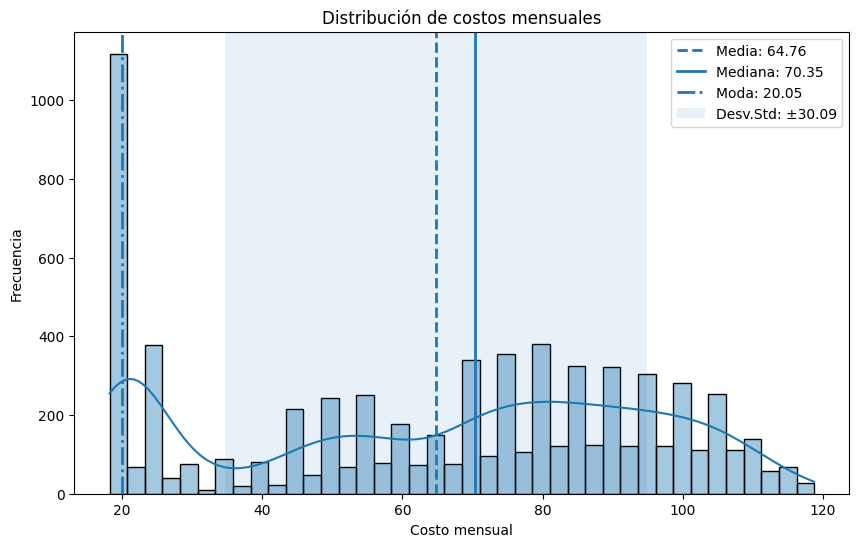

In [46]:
# seleccionar columnas
mensual = df['Cargo Mensual']
total = df['Cargo Total']

# métricas principales
print("📊 Estadísticas generales")
print(df[['Cargo Mensual','Cargo Total']].describe())

# moda
moda_mes = mensual.mode()[0]
moda_total = total.mode()[0]

print(f"\nModa mensual: {moda_mes}")
print(f"Moda total: {moda_total}")

# gráfico
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(mensual, bins=40, kde=True, alpha=0.4)

plt.axvline(mensual.mean(), linestyle="--", linewidth=2, label=f"Media: {mensual.mean():.2f}")
plt.axvline(mensual.median(), linestyle="-", linewidth=2, label=f"Mediana: {mensual.median():.2f}")
plt.axvline(moda_mes, linestyle="-.", linewidth=2, label=f"Moda: {moda_mes:.2f}")

plt.axvspan(
    mensual.mean() - mensual.std(),
    mensual.mean() + mensual.std(),
    alpha=0.1,
    label=f"Desv.Std: ±{mensual.std():.2f}"
)

plt.title("Distribución de costos mensuales")
plt.xlabel("Costo mensual")
plt.ylabel("Frecuencia")
plt.legend()

plt.show()

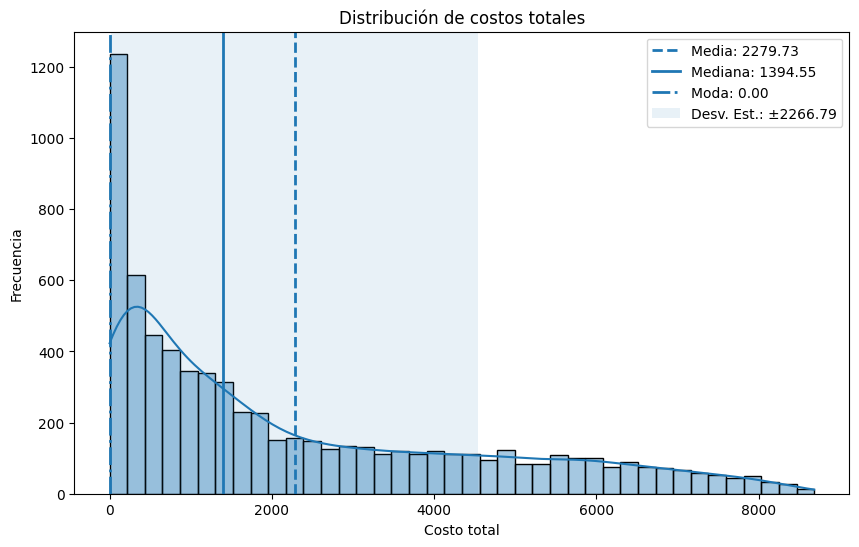

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

total = df['Cargo Total']

plt.figure(figsize=(10,6))

sns.histplot(total, bins=40, kde=True, alpha=0.4)

plt.axvline(total.mean(), linestyle='--', linewidth=2,
            label=f"Media: {total.mean():.2f}")

plt.axvline(total.median(), linestyle='-', linewidth=2,
            label=f"Mediana: {total.median():.2f}")

plt.axvline(total.mode()[0], linestyle='-.', linewidth=2,
            label=f"Moda: {total.mode()[0]:.2f}")

plt.axvspan(
    total.mean() - total.std(),
    total.mean() + total.std(),
    alpha=0.1,
    label=f"Desv. Est.: ±{total.std():.2f}"
)

plt.title("Distribución de costos totales")
plt.xlabel("Costo total")
plt.ylabel("Frecuencia")
plt.legend()

plt.show()

### Distribución de evasión

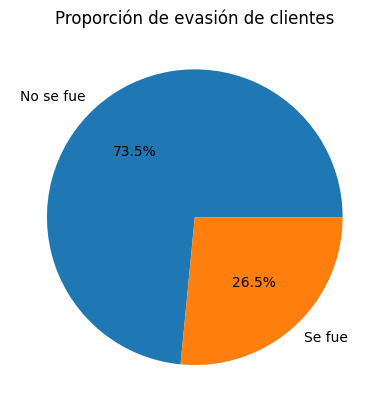

In [54]:
df['Abandono'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['No se fue', 'Se fue']
)

plt.title('Proporción de evasión de clientes')
plt.ylabel('')

plt.show()

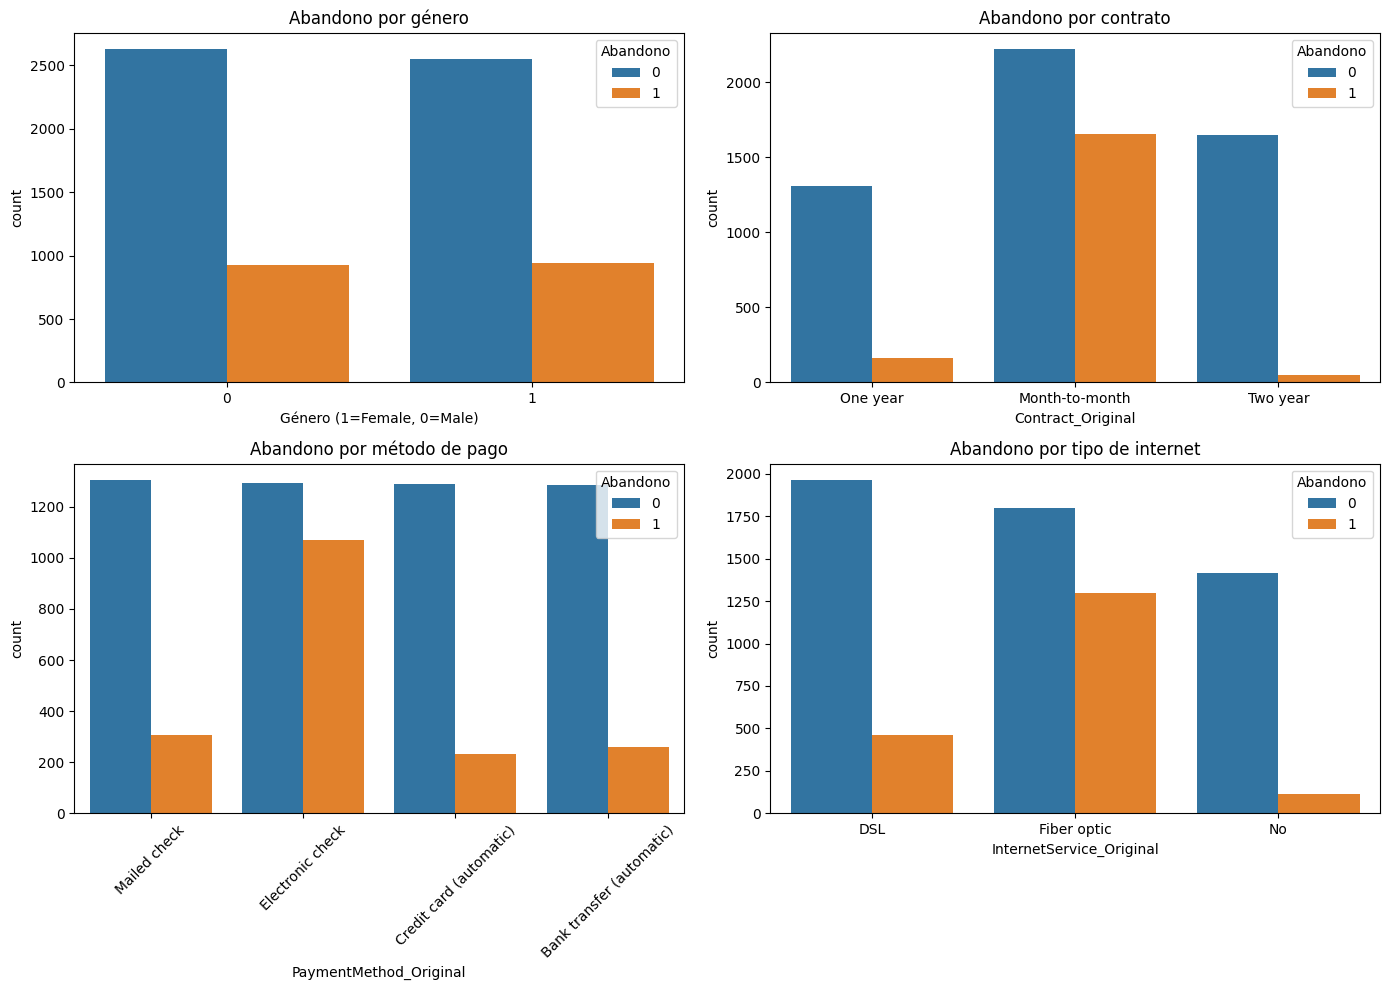

In [57]:
#Recuento de distribución de evasión

fig, axes = plt.subplots(2, 2, figsize=(14,10))

# Create temporary columns for plotting original categories from one-hot encoded columns
temp_df = df.copy()

temp_df['Contract_Original'] = temp_df.apply(
    lambda row: 'Month-to-month' if row['Contrato: Mes a Mes'] == 1 else \
                ('One year' if row['Contrato: Un Año'] == 1 else \
                 ('Two year' if row['Contrato: Dos Años'] == 1 else 'Unknown')),
    axis=1
)

temp_df['PaymentMethod_Original'] = temp_df.apply(
    lambda row: 'Bank transfer (automatic)' if row['Método de Pago: Transferencia Bancaria'] == 1 else \
                ('Credit card (automatic)' if row['Método de Pago: Tarjeta de Crédito'] == 1 else \
                 ('Electronic check' if row['Método de Pago: Cheque Electrónico'] == 1 else \
                  ('Mailed check' if row['Método de Pago: Cheque Enviado por Correo'] == 1 else 'Unknown'))),
    axis=1
)

temp_df['InternetService_Original'] = temp_df.apply(
    lambda row: 'DSL' if row['Internet: DSL'] == 1 else \
                ('Fiber optic' if row['Internet: Fibra Óptica'] == 1 else \
                 ('No' if row['Internet: No'] == 1 else 'Unknown')),
    axis=1
)


# Churn por género
sns.countplot(data=temp_df, x='Género', hue='Abandono', ax=axes[0,0])
axes[0,0].set_title('Abandono por género')
axes[0,0].set_xlabel('Género (1=Female, 0=Male)')

# Churn por tipo de contrato
sns.countplot(data=temp_df, x='Contract_Original', hue='Abandono', ax=axes[0,1])
axes[0,1].set_title('Abandono por contrato')

# Churn por método de pago
sns.countplot(data=temp_df, x='PaymentMethod_Original', hue='Abandono', ax=axes[1,0])
axes[1,0].set_title('Abandono por método de pago')
axes[1,0].tick_params(axis='x', rotation=45)

# Churn por servicio de internet
sns.countplot(data=temp_df, x='InternetService_Original', hue='Abandono', ax=axes[1,1])
axes[1,1].set_title('Abandono por tipo de internet')

plt.tight_layout()
plt.show()

### Conteo de evasión por variables numéricas

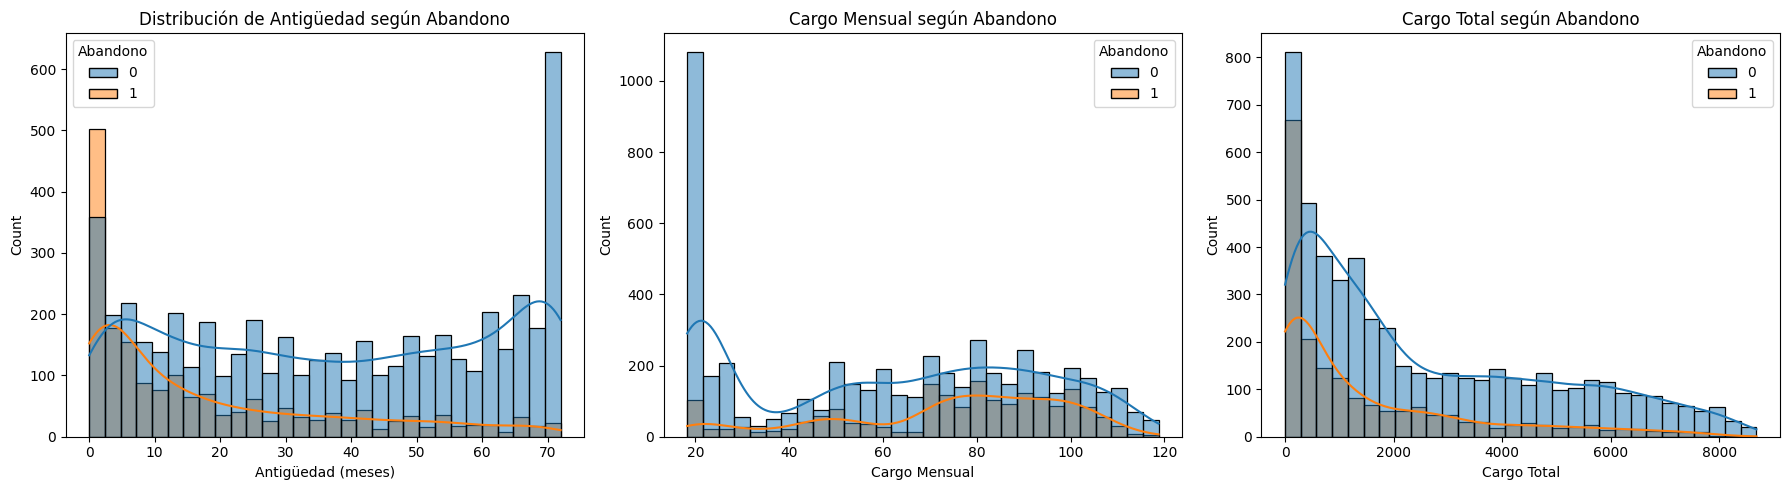

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Tenure
sns.histplot(data=df, x='Antigüedad (meses)', hue='Abandono', bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribución de Antigüedad según Abandono')

# Costo mensual
sns.histplot(data=df, x='Cargo Mensual', hue='Abandono', bins=30, kde=True, ax=axes[1])
axes[1].set_title('Cargo Mensual según Abandono')

# Costo total
sns.histplot(data=df, x='Cargo Total', hue='Abandono', bins=30, kde=True, ax=axes[2])
axes[2].set_title('Cargo Total según Abandono')

plt.tight_layout()
plt.show()

#📄Informe final

# 🔹 Introducción

El objetivo de este análisis es comprender los factores que influyen en la **evasión de clientes (Churn)** dentro de Telecom X. La empresa enfrenta una alta tasa de cancelación de servicios y necesita identificar los patrones que llevan a los clientes a abandonar la compañía.

A través del uso de **Python y bibliotecas de análisis de datos**, se realizó un proceso de **Extracción, Transformación y Análisis Exploratorio de Datos (EDA)** para identificar tendencias y comportamientos relacionados con la evasión.

Este análisis permitirá al equipo de **Data Science** desarrollar modelos predictivos y estrategias para **reducir la pérdida de clientes y mejorar la retención**.

---

# 🔹 Limpieza y Tratamiento de Datos

Durante esta etapa se aplicó el proceso **ETL (Extracción, Transformación y Carga)** para preparar los datos antes del análisis.

## Extracción de datos

Los datos fueron obtenidos desde una **API en formato JSON** y cargados en un DataFrame utilizando la biblioteca **pandas**.

## Exploración inicial

Se revisó la estructura del dataset utilizando:

- `DataFrame.info()`
- `DataFrame.describe()`
- `DataFrame.dtypes`

Esto permitió identificar:

- tipos de datos
- valores faltantes
- posibles inconsistencias

## Limpieza de datos

Se realizaron las siguientes acciones:

- Corrección de valores en la columna **account.Charges.Total**, eliminando espacios y convirtiendo los datos a formato numérico.
- Identificación y tratamiento de **valores faltantes**.
- Eliminación de registros con valores inválidos en la variable **Churn**.
- Revisión de **formatos inconsistentes en customerID**.
- Sustitución de valores como:
  No internet service
  No phone service

por valores consistentes (`No`).

## Manejo de inconsistencias

Para valores faltantes en **account.Charges.Total**, se realizó una estimación utilizando la siguiente relación:

Total Charges = tenure × Monthly Charges


Esto permitió completar registros incompletos y mantener la consistencia del dataset.

## Transformación de variables

Se aplicaron varias transformaciones para facilitar el análisis:

### Conversión de variables binarias

Las variables categóricas **Yes/No** se transformaron a valores numéricos:

Yes = 1
No = 0


Variables transformadas:

- Churn
- Partner
- Dependents
- PhoneService
- PaperlessBilling

### Codificación de variables categóricas

Se aplicó **One Hot Encoding** a variables como:

- tipo de contrato
- método de pago
- servicios de internet
- servicios adicionales

Esto permitió preparar los datos para análisis estadístico y posibles modelos predictivos.

---

# 🔹 Análisis Exploratorio de Datos (EDA)

## Estadísticas descriptivas

Se calcularon métricas estadísticas para comprender el comportamiento de las variables numéricas:

- Media
- Mediana
- Moda
- Desviación estándar

Variables analizadas:

- **account.Charges.Monthly**
- **account.Charges.Total**

### Resultados principales

- El **cargo mensual promedio** es de aproximadamente **64.76**.
- El **cargo total promedio** es de aproximadamente **2279.73**.
- Existe una **alta dispersión en el gasto total**, lo que indica gran variabilidad entre clientes.

También se visualizaron **histogramas de distribución** para analizar la forma de los datos y su dispersión.

---

## Distribución de evasión

Se analizó la proporción de clientes que abandonaron el servicio frente a los que permanecieron.

Los resultados muestran que:

- La mayoría de los clientes **continúan utilizando el servicio**.
- Sin embargo, existe una **proporción relevante de cancelaciones**, lo que representa una oportunidad importante para mejorar las estrategias de retención.

---

## Evasión según variables categóricas

Se analizaron variables como:

- género
- tipo de contrato
- método de pago
- facturación electrónica

Los resultados muestran patrones importantes:

- Los clientes con **contratos mes a mes presentan mayor tasa de evasión**.
- Los contratos **anuales o de dos años presentan menor churn**.
- Los clientes que utilizan **Electronic Check** presentan mayor probabilidad de cancelar el servicio.

---

## Evasión según variables numéricas

También se analizaron variables numéricas comparando clientes que cancelaron el servicio frente a los que permanecieron.

Variables analizadas:

- antigüedad del cliente (`tenure`)
- cargo mensual
- cargo total

### Resultados observados

- Los clientes con **menor antigüedad tienen mayor probabilidad de abandonar el servicio**.
- Los clientes con **mayor gasto acumulado tienden a permanecer más tiempo**.
- Los cargos mensuales más altos pueden estar asociados con mayor riesgo de cancelación.

---

# 🔹 Conclusiones e Insights

A partir del análisis realizado se identificaron varios factores asociados a la evasión de clientes.

## Principales hallazgos

### 1️⃣ La antigüedad del cliente es un factor clave

Los clientes nuevos presentan mayor probabilidad de cancelar el servicio.

---

### 2️⃣ El tipo de contrato influye en la retención

Los contratos **mes a mes presentan mayor tasa de churn**, mientras que los contratos de largo plazo ayudan a reducir la evasión.

---

### 3️⃣ El método de pago puede influir en la cancelación

Los clientes que utilizan **Electronic Check** presentan una mayor tendencia a cancelar el servicio.

---

### 4️⃣ El gasto total refleja fidelidad del cliente

Los clientes con mayor gasto acumulado suelen ser clientes más antiguos y con menor probabilidad de evasión.

---

# 🔹 Recomendaciones

Con base en los resultados obtenidos, se proponen las siguientes acciones estratégicas:

## Incentivar contratos de largo plazo

Ofrecer promociones o beneficios para clientes que adopten contratos de **1 o 2 años**, ya que estos presentan menor tasa de evasión.

---

## Fortalecer la retención de clientes nuevos

Implementar estrategias durante los **primeros meses del cliente**, como:

- promociones iniciales
- beneficios exclusivos
- seguimiento de satisfacción

---

## Analizar el método de pago Electronic Check

Investigar por qué los clientes que utilizan este método presentan mayor churn y promover métodos de pago automáticos.

---

## Programas de fidelización

Crear programas de fidelidad para clientes con mayor antigüedad, incluyendo:

- recompensas
- descuentos
- mejoras en el servicio

---

# 📌 Conclusión

El análisis permitió identificar **factores clave asociados a la evasión de clientes en Telecom X**.  

Los resultados obtenidos proporcionan información valiosa que puede ser utilizada para desarrollar **estrategias de retención más efectivas y mejorar la satisfacción de los clientes**.